Running on: cpu


100%|██████████| 170M/170M [00:03<00:00, 43.3MB/s]



---------------------------
Training with lambda=0.01
Epoch [1/20] Loss: 1.8514
Epoch [2/20] Loss: 1.5813
Epoch [3/20] Loss: 1.4646
Epoch [4/20] Loss: 1.3737
Epoch [5/20] Loss: 1.3017
Epoch [6/20] Loss: 1.2336
Epoch [7/20] Loss: 1.1773
Epoch [8/20] Loss: 1.1257
Epoch [9/20] Loss: 1.0735
Epoch [10/20] Loss: 1.0224
Epoch [11/20] Loss: 0.9750
Epoch [12/20] Loss: 0.9280
Epoch [13/20] Loss: 0.8836
Epoch [14/20] Loss: 0.8362
Epoch [15/20] Loss: 0.7891
Epoch [16/20] Loss: 0.7473
Epoch [17/20] Loss: 0.7040
Epoch [18/20] Loss: 0.6634
Epoch [19/20] Loss: 0.6255
Epoch [20/20] Loss: 0.5854
Lambda=0.01 Accuracy=55.00% Sparsity=0.59%

---------------------------
Training with lambda=0.05
Epoch [1/20] Loss: 1.8535
Epoch [2/20] Loss: 1.5790
Epoch [3/20] Loss: 1.4646
Epoch [4/20] Loss: 1.3810
Epoch [5/20] Loss: 1.3086
Epoch [6/20] Loss: 1.2441
Epoch [7/20] Loss: 1.1869
Epoch [8/20] Loss: 1.1294
Epoch [9/20] Loss: 1.0812
Epoch [10/20] Loss: 1.0272
Epoch [11/20] Loss: 0.9836
Epoch [12/20] Loss: 0.9365
E

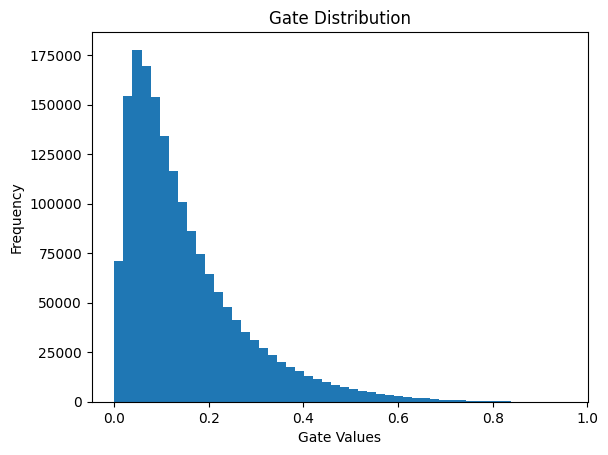

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running on:", device)

transform_pipeline = T.Compose([
    T.ToTensor(),
    T.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform_pipeline
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform_pipeline
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)


class GatedLinear(nn.Module):

    def __init__(self, input_dim, output_dim):

        super(GatedLinear, self).__init__()

        self.weights = nn.Parameter(
            torch.randn(output_dim, input_dim) * 0.01
        )

        self.bias = nn.Parameter(
            torch.zeros(output_dim)
        )

        self.gate_params = nn.Parameter(
            torch.randn(output_dim, input_dim) - 2
        )

    def forward(self, x):

        gate_values = torch.sigmoid(self.gate_params)

        effective_weights = self.weights * gate_values

        return F.linear(
            x,
            effective_weights,
            self.bias
        )


class SparseMLP(nn.Module):

    def __init__(self):

        super(SparseMLP, self).__init__()

        self.layer1 = GatedLinear(3072, 512)
        self.layer2 = GatedLinear(512, 256)
        self.layer3 = GatedLinear(256, 10)

    def forward(self, x):

        x = x.view(x.size(0), -1)

        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))

        return self.layer3(x)


def sparsity_penalty(model):

    penalty = 0
    count = 0

    for layer in model.modules():

        if isinstance(layer, GatedLinear):

            gate_vals = torch.sigmoid(
                layer.gate_params
            )

            penalty += gate_vals.mean()
            count += 1

    return penalty / count


def test_accuracy(model):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for imgs, lbls in test_loader:

            imgs = imgs.to(device)
            lbls = lbls.to(device)

            outputs = model(imgs)

            _, preds = torch.max(
                outputs.data,
                1
            )

            total += lbls.size(0)

            correct += (
                preds == lbls
            ).sum().item()

    return 100 * correct / total


def compute_sparsity(model, threshold=1e-2):

    total_params = 0
    pruned_params = 0

    for layer in model.modules():

        if isinstance(layer, GatedLinear):

            gate_vals = torch.sigmoid(
                layer.gate_params
            )

            total_params += gate_vals.numel()

            pruned_params += (
                gate_vals < threshold
            ).sum().item()

    return 100 * pruned_params / total_params


def train_network(model, lambda_val):

    loss_fn = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    epochs = 20

    model.train()

    for ep in range(epochs):

        epoch_loss = 0

        for imgs, lbls in train_loader:

            imgs = imgs.to(device)
            lbls = lbls.to(device)

            predictions = model(imgs)

            classification_loss = loss_fn(
                predictions,
                lbls
            )

            sparsity_loss = sparsity_penalty(
                model
            )

            final_loss = (
                classification_loss +
                lambda_val * sparsity_loss
            )

            optimizer.zero_grad()

            final_loss.backward()

            optimizer.step()

            epoch_loss += final_loss.item()

        print(
            f"Epoch [{ep+1}/{epochs}] "
            f"Loss: {epoch_loss/len(train_loader):.4f}"
        )

    return model


def plot_gate_histogram(model):

    all_gates = []

    for layer in model.modules():

        if isinstance(layer, GatedLinear):

            gate_vals = torch.sigmoid(
                layer.gate_params
            ).detach().cpu()

            all_gates.extend(
                gate_vals.flatten().numpy()
            )

    plt.figure()

    plt.hist(all_gates, bins=50)

    plt.title("Gate Distribution")

    plt.xlabel("Gate Values")

    plt.ylabel("Frequency")

    plt.savefig("gate_distribution.png")

    plt.show()


lambda_list = [
    1e-2,
    5e-2,
    1e-1
]

experiment_results = []

final_model = None

for lam in lambda_list:

    print("\n---------------------------")
    print(f"Training with lambda={lam}")

    net = SparseMLP().to(device)

    trained_net = train_network(
        net,
        lam
    )

    acc = test_accuracy(trained_net)

    sparsity_val = compute_sparsity(
        trained_net
    )

    experiment_results.append(
        (lam, acc, sparsity_val)
    )

    final_model = trained_net

    print(
        f"Lambda={lam} "
        f"Accuracy={acc:.2f}% "
        f"Sparsity={sparsity_val:.2f}%"
    )


print("\nFinal Results Summary")

for res in experiment_results:

    print(
        f"Lambda={res[0]} "
        f"Accuracy={res[1]:.2f}% "
        f"Sparsity={res[2]:.2f}%"
    )

plot_gate_histogram(final_model)